<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
 Automated Commodity Price Monitoring & Forecasting System For Lithium & Chemical Price 
 

</center></p></h1>


<div style="border-radius: 5px; -webkit-border-radius: 5px; -moz-border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF"> <p style="text-align: center; font-family: cursive; font-size: 16px; color : green ; font-weight : bold"> Automated Commodity Price Monitoring & Forecasting System </p> <hr style="border: 1px solid #008000;"> <p><b>Objective:</b></p> <ul> <li>Develop a fully automated system to track, analyze, forecast, and report global commodity price movements for critical battery, electrolyzer components, and chemical materials.</li> </ul> <p><b>Aim:</b></p> <ul> <li>Help industries reduce procurement risks by providing real-time price monitoring, trend visualization, forecasting, and automated alerts.</li> </ul> <p><b>Solution Developed:</b></p> <ul> <li><b>Real-time price scraping</b> from reliable global market sources (TradingEconomics, Fuel Cell Store, SunSirs.com).</li> <li><b>Automated data cleaning & storage</b> into date-stamped Excel files and a unified master CSV database.</li> <li><b>Interactive Streamlit dashboard</b> with charts, filters, comparisons, and historical trend visualization.</li> <li><b>Machine-learning forecasting</b> using ARIMA and Prophet models to predict short-term commodity price trends.</li> <li><b>Email alert system</b> that triggers when price fluctuations exceed user-defined thresholds (e.g., ±10%).</li> <li><b>Scheduled automation</b> (daily) running entirely without manual intervention.</li> </ul> <p><b>Impact:</b></p> <ul> <li>Addresses a real industrial need by protecting companies from sudden market volatility.</li> <li>Demonstrates end-to-end capability in web scraping, automation pipelines, forecasting, dashboards, and reporting.</li> <li>Provides a production-ready, scalable solution for procurement teams and financial analysts.</li> </ul>

<div style="border-radius: 5px; border: 3px solid #008000; padding: 12px; background:#F2FFFF; font-family: cursive; color:black; font-size:14px; text-align: justify;">

<p style="text-align: center; font-size: 16px; font-weight: bold; color: green;">
Problem Statement – Industry Challenges in Chemical Price Monitoring
</p>

<hr style="border: 1px solid #008000;">

<p>
Many manufacturing, battery, and chemical companies face persistent challenges in tracking and responding to daily fluctuations in global commodity prices. These difficulties create significant risk for procurement teams and result in inefficient, manual workflows.
</p>

<p><b>Key Problems:</b></p>
<ul>
    <li>Inconsistent or delayed access to up-to-date chemical price data and Fuel cell/electrolyzer componets price.</li>
    <li>Manual price checking across multiple websites without automation.</li>
    <li>No forecasting tools to support procurement planning and budgeting.</li>
    <li>Lack of automated alerts during major market price swings.</li>
    <li>Difficulty aggregating and harmonizing data from different market sources.</li>
</ul>



<p>
In industries where even a <b>10–20% shift in commodity price</b> can impact millions in raw material cost, having accurate and timely insights is essential for strategic decision-making.
</p>

<p>
To address these gaps, I designed and developed an <b>automated intelligence pipeline</b> that continuously monitors commodity markets, forecasts trends, and transforms raw price data into actionable insights for procurement and strategy teams.
</p>

</div>


<div style="border-radius: 5px; border: 3px solid #008000; padding: 12px; background:#F2FFFF; font-family: cursive; color:black; font-size:14px; text-align: justify;">

<p style="text-align: center; font-size: 16px; font-weight: bold; color: green;">Forecasting Commodity Prices Using Prophet & TimeSeriesSplit</p>

<p><strong>Goal:</strong> Predict future commodity prices (e.g., Lithium carbonate) and validate the model’s accuracy on historical data.</p>

<p><strong>Step 1: Prepare Data</strong><br>
Convert historical price data into Prophet format: <em>ds = date</em>, <em>y = price</em>. Remove timezone information for compatibility.</p>

<p><strong>Step 2: Time Series Cross-Validation (TimeSeriesSplit)</strong><br>
Instead of random splits, <em>TimeSeriesSplit</em> keeps the data in chronological order. It divides data into sequential training and test sets, simulating real-world forecasting. For each split, the model is trained on past data and tested on future data, computing metrics like RMSE and R².</p>

<p><strong>Step 3: Fit Full Model for Future Forecast</strong><br>
After validation, Prophet is trained on the entire dataset to predict future prices for N days (e.g., 30 days). This generates forecasts with upper and lower confidence bounds.</p>

<p><strong>Step 4: Visualization</strong><br>
Plot the actual prices, predicted prices, and confidence intervals. Confidence intervals show the likely range of true future prices.</p>

<p><strong>Why This Method is Powerful:</strong></p>
<ul>
<li>Respects time order – avoids peeking into the future.</li>
<li>Handles seasonality – models weekly, yearly, and other patterns.</li>
<li>Quantifies uncertainty – provides confidence intervals.</li>
<li>Scalable – can forecast multiple commodities.</li>
</ul>

</div>



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
from prophet import Prophet
import plotly.graph_objects as go
import os, schedule, time,csv
import smtplib
from email.message import EmailMessage
from prophet import Prophet
from forex_python.converter import CurrencyRates
import matplotlib.pyplot as plt
from time import sleep
from datetime import datetime
import math
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Use Webscraping to Extract Data From Fuel Cell Store

</center></p></h1>

In [ ]:
chemical_urls = {
    "Catalyst": "https://www.fuelcellstore.com/fuel-cell-components/catalyst",
    "Electrodes": "https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode",
    "Gas Diffusion Layers": "https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-layers",
    "Membrane Electrode Assemblies": "https://www.fuelcellstore.com/fuel-cell-components/membrane-electrode-assembly",
    "Membranes": "https://www.fuelcellstore.com/fuel-cell-components/membranes",
    "Battery Materials": "https://www.fuelcellstore.com/battery-materials-anode-cathode-powders"}

header = {"User-Agent": "Mozilla/5.0"}

for name, url in chemical_urls.items():
    print(f"\n🔍 Fetching: {name} | {url}")

    try:
        page = requests.get(url, headers=header)
        print("✅ Success", page.status_code)
    except Exception as e:
        print("❌ Error:", e)
        continue

    soup = BeautifulSoup(page.text, "html.parser")


🔍 Fetching: Catalyst | https://www.fuelcellstore.com/fuel-cell-components/catalyst
✅ Success 200

🔍 Fetching: Electrodes | https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode
✅ Success 200

🔍 Fetching: Gas Diffusion Layers | https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-layers
✅ Success 200

🔍 Fetching: Membrane Electrode Assemblies | https://www.fuelcellstore.com/fuel-cell-components/membrane-electrode-assembly
✅ Success 200

🔍 Fetching: Membranes | https://www.fuelcellstore.com/fuel-cell-components/membranes
✅ Success 200

🔍 Fetching: Battery Materials | https://www.fuelcellstore.com/battery-materials-anode-cathode-powders
✅ Success 200


In [ ]:
for name, base_url in chemical_urls.items():

    filename = f"{name.replace(' ', '_')}.csv"
    print(f"\n🔍 Scraping category: {name} → {filename}")

    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Category", "Title", "Price", "Description", "Rating", "Link"])

        # loop through first 4 pages
        for page_num in range(1, 5):
            if page_num == 1:
                url = base_url
            else:
                chemical_urls = f"{base_url}?page={page_num}"

            print(f"  📝 Fetching page {page_num}: {url}")
            page = requests.get(url, headers=header)
            soup = BeautifulSoup(page.text, "html.parser")
            products = soup.find_all("div", class_="caption")

            for item in products:

                # Title
                try:
                    title = item.find("a").text.strip()
                except:
                    title = "NA"

                # Price
                try:
                    price = item.select_one(".price").text.strip()
                except:
                    price = "NA"

                # Description
                try:
                    desc = item.find("p", class_="short-description")
                    if desc is None:
                        desc = item.find("div", class_="short-description")
                    description = desc.text.strip()
                except:
                    description = "NA"

                # Rating (not available)
                rating = "NA"

                # Link
                try:
                    link = item.find("a").get("href")
                    if not link.startswith("http"):
                        link = "https://www.fuelcellstore.com" + link
                except:
                    link = "NA"

                writer.writerow([name, title, price, description, rating, link])

    print(f"✔ Completed: {filename}")


🔍 Scraping category: Catalyst → Catalyst.csv
  📝 Fetching page 1: https://www.fuelcellstore.com/fuel-cell-components/catalyst
  📝 Fetching page 2: https://www.fuelcellstore.com/fuel-cell-components/catalyst?page=2
  📝 Fetching page 3: https://www.fuelcellstore.com/fuel-cell-components/catalyst?page=3
  📝 Fetching page 4: https://www.fuelcellstore.com/fuel-cell-components/catalyst?page=4
✔ Completed: Catalyst.csv

🔍 Scraping category: Electrodes → Electrodes.csv
  📝 Fetching page 1: https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode
  📝 Fetching page 2: https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode?page=2
  📝 Fetching page 3: https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode?page=3
  📝 Fetching page 4: https://www.fuelcellstore.com/fuel-cell-components/gas-diffusion-electrode?page=4
✔ Completed: Electrodes.csv

🔍 Scraping category: Gas Diffusion Layers → Gas_Diffusion_Layers.csv
  📝 Fetching page 1: https://w

In [28]:
captions = soup.find_all("div", class_="caption")

links = []

for cap in captions:
    a_tag = cap.find("a")
    if a_tag:
        links.append(a_tag.get("href"))


print(links)

['https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/lithium-manganese-nickel-cobalt-oxide-nmc811-cbp-56-cathode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/lithium-manganese-nickel-cobalt-oxide-nmc622-cathode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/carbon-coated-lithium-titanate-be-10c-anode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/lithium-manganese-nickel-cobalt-oxide-nmc111-cathode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/linbo3-coated-lithium-manganese-nickel-cobalt-oxide-nmc811-cathode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/linbo3-coated-lithium-manganese-nickel-cobalt-oxide-nmc622', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/lithium-manganese-oxide-be-30-cathode-powder', 'https://www.fuelcellstore.com/battery-materials-anode-cathode-powders/l

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
  tradingeconomics Webscraping to Extract Data 

</center></p></h1>

In [ ]:
header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 \
                   (KHTML, like Gecko) Chrome/118.0.5993.90 Safari/537.36"}




titles, descriptions, links, dates = [], [], [], []

for page in range(1, 4):  # scrape first 3 pages
    url = f'https://tradingeconomics.com/commodity/lithium/{page}'
    r = requests.get(url, headers=header)
    soup = BeautifulSoup(r.text, 'html.parser')
    print(soup.prettify()[:1000])
    

    posts = soup.select('div.card-header')
    for post in posts:
        # Extract title
        a_tag = post.select_one('a')
        titles.append(a_tag.text.strip() if a_tag else "")

        # Extract link
        links.append(a_tag['href'] if a_tag else "")

        # Extract description (if available)
        desc_tag = post.select_one('div.comment more')
        descriptions.append(desc_tag.text.strip() if desc_tag else "")

        # Extract date 
        date_tag = post.select_one('.te-stream-date')
        dates.append(date_tag.text.strip() if date_tag else "")

    sleep(1)  # polite delay between requests

# Create DataFrame
df = pd.DataFrame({
    "Title": titles,
    "Description": descriptions,
    "Link": links,
    "Date": dates
})

df.head()

<!DOCTYPE html>
<html>
 <head id="ctl00_Head1">
  <meta charset="utf-8"/>
  <title>
   TRADING ECONOMICS | 20 Million Indicators for 196 Countries
  </title>
  <meta content="Get Free Economic Indicators Charts, Historical Data and Forecasts for 196 Countries." id="metaDesc" name="description"/>
  <meta content="Economic Indicators, Data, Charts" id="metaKeyword" name="keywords"/>
  <meta content="width=device-width,minimum-scale=1,initial-scale=1,maximum-scale=1" name="viewport"/>
  <meta content="#333333" name="theme-color"/>
  <link crossorigin="anonymous" href="https://d3e5kp2e91w0k0.cloudfront.net" rel="preconnect"/>
  <link crossorigin="anonymous" href="https://d2n2sd20z6hutz.cloudfront.net" rel="preconnect"/>
  <link crossorigin="anonymous" href="https://cdnjs.cloudflare.com" rel="preconnect"/>
  <link crossorigin="anonymous" href="https://cdnjs.cloudflare.com/ajax/libs/bootstrap/5.2.3/css/bootstrap.min.css" integrity="sha512-SbiR/eusphKoMVVXysTKG/7VseWii+Y3FdHrt0EpKgpToZeemhqHe

,Title,Description,Link,Date
0,,,,
1,,,,
2,,,,


In [109]:
# Add today's date
today = datetime.now().strftime("%Y-%m-%d")
df['Scrape Date'] = today

# Save CSV
filename = f"trans_news_Posts_{today}.csv"
df.to_csv(filename, index=False)
print(f"CSV file saved as {filename}")

CSV file saved as trans_news_Posts_2025-11-24.csv


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
  SunSirs Webscraping to Extract Data 

</center></p></h1>

In [3]:
sunsir_urls = {
    "Soda ash": "https://www.sunsirs.com/futures-price/petail-Soda-ash-737.html",
    "Copper": "https://www.sunsirs.com/futures-price/petail-Copper-792.html",
    "Caustic soda": "https://www.sunsirs.com/futures-price/petail-Caustic-soda-368.html",
    "Lithium carbonate": "https://www.sunsirs.com/futures-price/petail-Lithium-carbonate-1162.html",
}

header = {"User-Agent": "Mozilla/5.0"}

usd_to_cad = 1.37  # update if needed, convert YAN to CAD
all_data = []

for name, url in sunsir_urls.items():
    print(f"\n🔍 Fetching: {name} | {url}")

    try:
        page = requests.get(url, headers=header)
        print("✅ Success", page.status_code)
    except Exception as e:
        print("❌ Error:", e)
        continue




🔍 Fetching: Soda ash | https://www.sunsirs.com/futures-price/petail-Soda-ash-737.html
✅ Success 200

🔍 Fetching: Copper | https://www.sunsirs.com/futures-price/petail-Copper-792.html
✅ Success 200

🔍 Fetching: Caustic soda | https://www.sunsirs.com/futures-price/petail-Caustic-soda-368.html
✅ Success 200

🔍 Fetching: Lithium carbonate | https://www.sunsirs.com/futures-price/petail-Lithium-carbonate-1162.html
✅ Success 200


In [4]:
soup_text = BeautifulSoup(page.text, "html.parser")

In [6]:
tables1 = soup_text.find_all("table")
tables1

[<table class="xnn-tablea">
 <tr>
 <td width="20%">Commodity</td>
 <td width="25%">Dominant contract</td>
 <td width="25%">Spot price</td>
 <td width="15%">Date</td>
 </tr>
 <tr><td>Lithium carbonate</td><td>94960</td><td>92266.7</td><td>2025-11-25</td></tr><tr><td>Lithium carbonate</td><td>91320</td><td>92266.7</td><td>2025-11-24</td></tr><tr><td>Lithium carbonate</td><td>93160</td><td>94266.7</td><td>2025-11-21</td></tr><tr><td>Lithium carbonate</td><td>100020</td><td>95266.7</td><td>2025-11-20</td></tr><tr><td>Lithium carbonate</td><td>98160</td><td>95266.7</td><td>2025-11-19</td></tr><tr><td>Lithium carbonate</td><td>94600</td><td>90266.7</td><td>2025-11-18</td></tr>
 </table>]

In [9]:
rows = soup_text.find_all("tr")
rows

[<tr>
 <td width="20%">Commodity</td>
 <td width="25%">Dominant contract</td>
 <td width="25%">Spot price</td>
 <td width="15%">Date</td>
 </tr>,
 <tr><td>Lithium carbonate</td><td>94960</td><td>92266.7</td><td>2025-11-25</td></tr>,
 <tr><td>Lithium carbonate</td><td>91320</td><td>92266.7</td><td>2025-11-24</td></tr>,
 <tr><td>Lithium carbonate</td><td>93160</td><td>94266.7</td><td>2025-11-21</td></tr>,
 <tr><td>Lithium carbonate</td><td>100020</td><td>95266.7</td><td>2025-11-20</td></tr>,
 <tr><td>Lithium carbonate</td><td>98160</td><td>95266.7</td><td>2025-11-19</td></tr>,
 <tr><td>Lithium carbonate</td><td>94600</td><td>90266.7</td><td>2025-11-18</td></tr>]

In [10]:
data = []

for row in rows[1:]:
    cols = row.find_all('td')
    cols_text = [col.text.strip() for col in cols]
    data.append(cols_text)

In [12]:
columns = ['Commodity', 'Dominant contract', 'Spot price', 'Date']
df = pd.DataFrame(data, columns=columns)

df.head()

,Commodity,Dominant contract,Spot price,Date
0,Lithium carbonate,94960,92266.7,2025-11-25
1,Lithium carbonate,91320,92266.7,2025-11-24
2,Lithium carbonate,93160,94266.7,2025-11-21
3,Lithium carbonate,100020,95266.7,2025-11-20
4,Lithium carbonate,98160,95266.7,2025-11-19


In [39]:

header = {"User-Agent": "Mozilla/5.0"}


# --------------------------------------------
# FUNCTION — scrape single Sunsirs URL
# --------------------------------------------
def scrape_from_url(name, url):

    print(f"\n🔍 Fetching: {name} | {url}")

    page = requests.get(url, headers=header)
    soup = BeautifulSoup(page.text, "html.parser")

    table = soup.find("table")
    if table is None:
        print(f"⚠️ No table found for {name}")
        return pd.DataFrame()

    rows = table.find_all("tr")

    data = []
    for row in rows[1:]:                # skip header row
        cols = row.find_all("td")
        cols_text = [col.text.strip() for col in cols]
        data.append(cols_text)

    # Create DataFrame
    columns = ['Commodity', 'Dominant contract', 'Spot price', 'Date']
    df = pd.DataFrame(data, columns=columns)

    # Add commodity name
    df['Commodity'] = name


    return df


In [40]:
sunsir_urls = {
    "Soda ash": "https://www.sunsirs.com/futures-price/petail-Soda-ash-737.html",
    "Copper": "https://www.sunsirs.com/futures-price/petail-Copper-792.html",
    "Caustic soda": "https://www.sunsirs.com/futures-price/petail-Caustic-soda-368.html",
    "Lithium carbonate": "https://www.sunsirs.com/futures-price/petail-Lithium-carbonate-1162.html",
}

all_dfs = []

for name, url in sunsir_urls.items():
    df_single = scrape_from_url(name, url)
    all_dfs.append(df_single)

# Combine all dataframes
df_final = pd.concat(all_dfs, ignore_index=True)

print(df_final.head())



🔍 Fetching: Soda ash | https://www.sunsirs.com/futures-price/petail-Soda-ash-737.html

🔍 Fetching: Copper | https://www.sunsirs.com/futures-price/petail-Copper-792.html

🔍 Fetching: Caustic soda | https://www.sunsirs.com/futures-price/petail-Caustic-soda-368.html

🔍 Fetching: Lithium carbonate | https://www.sunsirs.com/futures-price/petail-Lithium-carbonate-1162.html
  Commodity Dominant contract Spot price        Date
0  Soda ash              1175    1207.86  2025-11-25
1  Soda ash              1176    1207.86  2025-11-24
2  Soda ash              1171    1207.14  2025-11-21
3  Soda ash              1169    1207.14  2025-11-20
4  Soda ash              1193       1215  2025-11-19


In [41]:
df_final.head(10)

,Commodity,Dominant contract,Spot price,Date
0,Soda ash,1175,1207.86,2025-11-25
1,Soda ash,1176,1207.86,2025-11-24
2,Soda ash,1171,1207.14,2025-11-21
3,Soda ash,1169,1207.14,2025-11-20
4,Soda ash,1193,1215,2025-11-19
5,Soda ash,1220,1218.57,2025-11-18
6,Copper,86420,86603.3,2025-11-25
7,Copper,86040,86285,2025-11-24
8,Copper,86000,85891.7,2025-11-21
9,Copper,86380,86461.7,2025-11-20


In [42]:
df_final.tail(10)

,Commodity,Dominant contract,Spot price,Date
14,Caustic soda,2254,824,2025-11-21
15,Caustic soda,2264,824,2025-11-20
16,Caustic soda,2276,824,2025-11-19
17,Caustic soda,2279,824,2025-11-18
18,Lithium carbonate,94960,92266.7,2025-11-25
19,Lithium carbonate,91320,92266.7,2025-11-24
20,Lithium carbonate,93160,94266.7,2025-11-21
21,Lithium carbonate,100020,95266.7,2025-11-20
22,Lithium carbonate,98160,95266.7,2025-11-19
23,Lithium carbonate,94600,90266.7,2025-11-18


In [ ]:
df_final.to_csv("df_final_1.csv", index=False)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Plotly bar chart

</center></p></h1>

In [43]:
# --------------------------------------------
# Clean and plot
# --------------------------------------------
df_clean = df_final.copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean = df_clean.sort_values('Date')
df_clean['Spot price'] = df_clean['Spot price'].str.replace(',', '').astype(float)  # ensure numeric

# Calculate % change
df_clean['Daily % Change'] = df_clean['Spot price'].pct_change() * 100
df_plot = df_clean.dropna(subset=['Daily % Change'])

# Color bars
colors = ['green' if x >= 0 else 'red' for x in df_plot['Daily % Change']]

# Plotly bar chart
fig = go.Figure(go.Bar(
    x=df_plot['Date'].dt.strftime('%Y-%m-%d'),
    y=df_plot['Daily % Change'],
    marker_color=colors,
    text=df_plot['Daily % Change'].map(lambda x: f"{x:.2f}%"),
    textposition='auto',
    name='Daily % Change'
))

fig.update_layout(
    title="Daily % Change of Spot Price",
    xaxis=dict(title="Date", type='category', tickmode='linear', rangeslider=dict(visible=True)),
    yaxis=dict(title="Daily % Change (%)"),
    template="plotly_white"
)

fig.show()

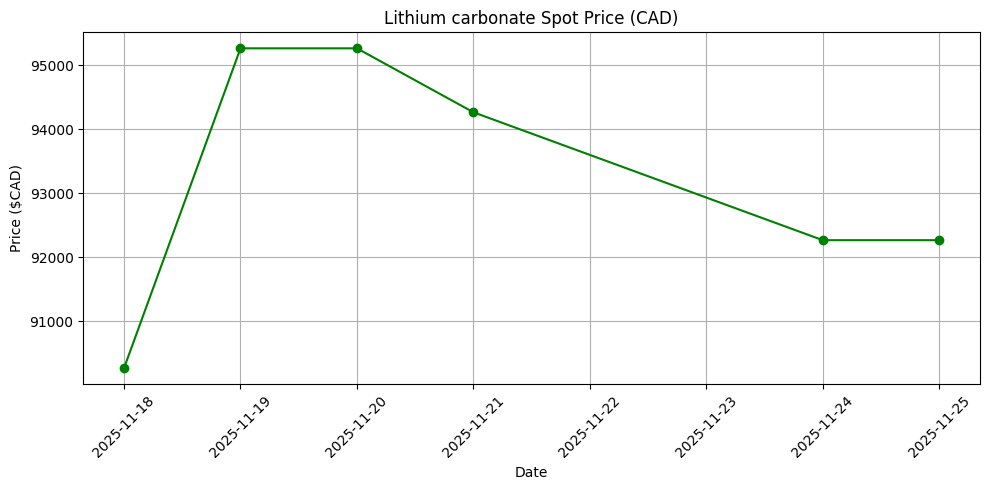

In [47]:


# Ensure Date column is datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

#  Plot single commodity
commodity = 'Lithium carbonate'
df_single = df_clean[df_clean['Commodity'] == commodity]

plt.figure(figsize=(10,5))
plt.plot(df_single['Date'], df_single['Spot price'], marker='o', color='green')
plt.title(f"{commodity} Spot Price (CAD)")
plt.xlabel("Date")
plt.ylabel("Price ($CAD)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Prophet Forecast Function

</center></p></h1>

In [52]:
def prophet_forecast(df, periods=30):
    # Ensure datetime
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Use 'Close' column for Prophet
    df_prophet = df[['Date','Close']].rename(columns={'Date':'ds','Close':'y'})
    df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # Compute RMSE and R²
    merged = forecast[['ds','yhat']].merge(df_prophet, on='ds', how='left')
    hist = merged[merged['y'].notna()]
    rmse = math.sqrt(mean_squared_error(hist['y'], hist['yhat']))
    r2 = r2_score(hist['y'], hist['yhat'])

    return model, forecast, rmse, r2


In [55]:
commodity = 'Lithium carbonate'
df_commodity = df_final[df_final['Commodity'] == commodity].sort_values('Date')

model, forecast, rmse, r2 = prophet_forecast(df_commodity, periods=30)
print(f"{commodity} — RMSE: {rmse:.2f}, R²: {r2:.2f}")

01:32:20 - cmdstanpy - INFO - Chain [1] start processing
01:32:20 - cmdstanpy - INFO - Chain [1] done processing


Lithium carbonate — RMSE: 0.01, R²: 1.00


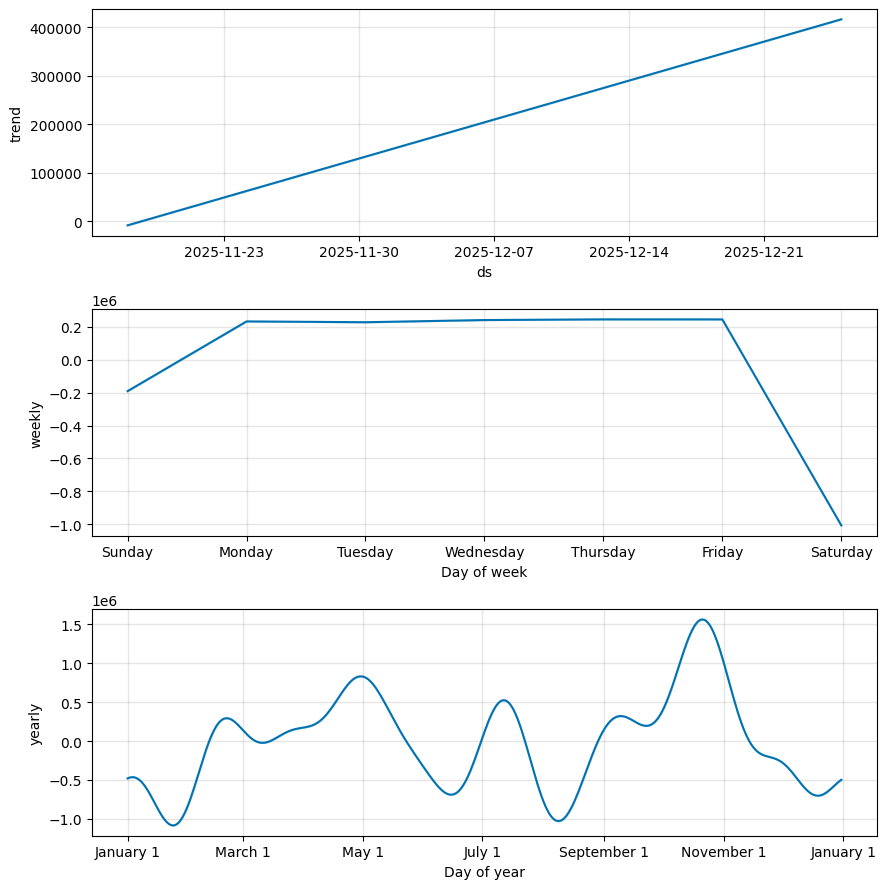

In [56]:
# ---- Plot Forecast (Plotly) ----
fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=df_final['Date'], y=df_final['Close'], mode='lines+markers', name='Actual'))
fig3.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Forecast'))
fig3.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', line=dict(dash='dot'), name='Lower Bound'))
fig3.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', line=dict(dash='dot'), name='Upper Bound'))
fig3.update_layout(title="Commodity Forecast - 30 Days", xaxis_title="Date", yaxis_title="Price (CAD/Ton)", template="plotly_white")
fig3.show()

# ---- Optional Prophet Components ----
model.plot_components(forecast)
plt.show()

In [ ]:


df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final = df_final.sort_values('Date')

# انتخاب کالا
commodity = 'Lithium carbonate'
df_commodity = df_final[df_final['Commodity'] == commodity].copy()
df_commodity['Close'] = df_commodity['Spot price'].astype(float)

# ساخت ستون Prophet
df_prophet = df_commodity[['Date', 'Close']].rename(columns={'Date':'ds','Close':'y'})
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

# -------------------- اعتبارسنجی زمانی --------------------
tscv = TimeSeriesSplit(n_splits=5)
rmse_list = []
r2_list = []

for train_idx, test_idx in tscv.split(df_prophet):
    train_df = df_prophet.iloc[train_idx]
    test_df = df_prophet.iloc[test_idx]

    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(train_df)

    future = test_df[['ds']]
    forecast = model.predict(future)

    rmse = math.sqrt(mean_squared_error(test_df['y'], forecast['yhat']))
    r2 = r2_score(test_df['y'], forecast['yhat'])

    rmse_list.append(rmse)
    r2_list.append(r2)

print(f"Average RMSE: {np.mean(rmse_list):.2f}")
print(f"Average R²: {np.mean(r2_list):.2f}")

# -------------------- پیش‌بینی آینده --------------------
model_full = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model_full.fit(df_prophet)

future_full = model_full.make_future_dataframe(periods=30)  # پیش‌بینی 30 روز آینده
forecast_full = model_full.predict(future_full)

# -------------------- نمودار --------------------
fig = go.Figure()

# داده‌های واقعی
fig.add_trace(go.Scatter(x=df_prophet['ds'], y=df_prophet['y'],
                         mode='lines+markers', name='Actual'))

# پیش‌بینی کامل
fig.add_trace(go.Scatter(x=forecast_full['ds'], y=forecast_full['yhat'],
                         mode='lines', name='Forecast'))

# محدوده اطمینان
fig.add_trace(go.Scatter(x=forecast_full['ds'], y=forecast_full['yhat_upper'],
                         fill=None, mode='lines', line=dict(color='lightgrey'), showlegend=False))
fig.add_trace(go.Scatter(x=forecast_full['ds'], y=forecast_full['yhat_lower'],
                         fill='tonexty', mode='lines', line=dict(color='lightgrey'),
                         name='Confidence Interval'))

fig.update_layout(title=f"{commodity} — Prophet Forecast with TimeSeriesSplit",
                  xaxis_title='Date', yaxis_title='Price (CAD)',
                  template='plotly_white')
fig.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Automate and EMAIL

</center></p></h1>

In [57]:


def send_email_alert(alerts, attachment_file):
    if not alerts:
        return  # no alerts to send
    
    msg = EmailMessage()
    msg['Subject'] = "Sunsir Commodity Alerts"
    msg['From'] = "you@example.com"
    msg['To'] = "recipient@example.com"
    msg.set_content("\n".join(alerts))

    with open(attachment_file, "rb") as f:
        msg.add_attachment(f.read(), maintype="application", subtype="csv", filename=attachment_file)

    with smtplib.SMTP("smtp.example.com", 587) as server:
        server.starttls()
        server.login("you@example.com", "password")
        server.send_message(msg)

    print("📧 Email sent!")


In [ ]:
if __name__ == "__main__":
    print("Scheduler started...")
    while True:
        schedule.run_pending()
        time.sleep(60)  # check every minute

Scheduler started...
